[![Labellerr](https://storage.googleapis.com/labellerr-cdn/%200%20Labellerr%20template/notebook.webp)](https://www.labellerr.com)

# **VLM OCR Model Comparision**

---

[![labellerr](https://img.shields.io/badge/Labellerr-BLOG-black.svg)](https://www.labellerr.com/blog/<BLOG_NAME>)
[![Youtube](https://img.shields.io/badge/Labellerr-YouTube-b31b1b.svg)](https://www.youtube.com/@Labellerr)
[![Github](https://img.shields.io/badge/Labellerr-GitHub-green.svg)](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)

This notebook is for comparision of two popular VLM OCR models on various scenario i.e GLM-OCR and Paddle OCR using LM STUDIO.

## IMPORT PACKAGES

In [16]:
from pathlib import Path
from dataclasses import asdict, dataclass
from IPython.display import Image, display, HTML
import lmstudio as lms
import html

## LOAD THE OCR MODEL

Before loading, make sure to download both model from lm-studio and also start the lms server

In [2]:
# Cell: load both models — cheap even if already loaded, just returns the handle
GLM_OCR_MODEL = "glm-ocr"
PADDLEOCR_MODEL = "paddlepaddle/paddleocr-vl-1.6-gguf/paddleocr-vl-1.6-gguf.gguf"

glm_model = lms.llm(GLM_OCR_MODEL)
print("Loaded model:", glm_model)

paddle_model = lms.llm(PADDLEOCR_MODEL)
print("Loaded model:", paddle_model)

Loaded model: LLM(identifier='glm-ocr')
Loaded model: LLM(identifier='paddlepaddle/paddleocr-vl-1.6-gguf/paddleocr-vl-1.6-gguf.gguf')


## Helper Functions

In [11]:
@dataclass(frozen=True)
class OCRResult:
    model: str
    text: str

def perform_ocr(
    image_path: str | Path,
    *,
    model: str,
    OCR_PROMPT: str,
) -> OCRResult:
    path = Path(image_path).expanduser()
    if not path.is_file():
        raise FileNotFoundError(f"Image does not exist: {path}")

    model_handle = lms.llm(model)
    if not model_handle.get_info().vision:
        raise RuntimeError(
            f"{model!r} has no vision/mmproj loaded — check the model's file list in LM Studio."
        )

    image_handle = lms.prepare_image(str(path))
    chat = lms.Chat()
    chat.add_user_message(OCR_PROMPT, images=[image_handle])

    prediction = model_handle.respond(chat, config={"temperature": 0})

    text = prediction.content
    if not text:
        raise RuntimeError("The OCR model returned no text")

    return OCRResult(model=model, text=text.strip())

In [17]:
def show_side_by_side(results):
    cols = "".join(
        f"""
        <td style="vertical-align:top; padding:12px; border:1px solid #555; width:{100 // len(results)}%;">
            <h4 style="margin-top:0;">{html.escape(r.model)}</h4>
            <pre style="white-space:pre-wrap; font-family:inherit; font-size:0.85em; max-height:500px; overflow-y:auto; margin:0;">{html.escape(r.text)}</pre>
        </td>
        """
        for r in results
    )
    display(HTML(f'<table style="width:100%; border-collapse:collapse; table-layout:fixed;"><tr>{cols}</tr></table>'))


## SIMPLE OCR

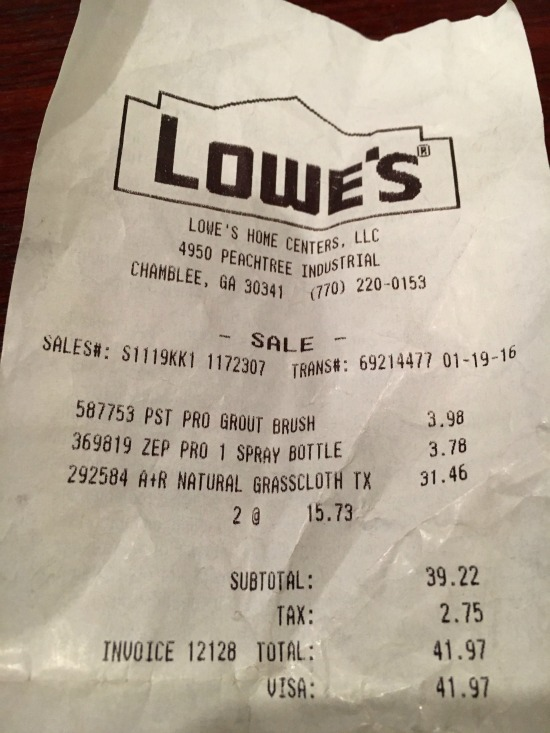

In [25]:
IMAGE_PATH = "sample_data/Receipt2.jpg"
display(Image(filename=IMAGE_PATH, width=400))

In [26]:
PROMPT = "OCR:"
results = [
    perform_ocr(IMAGE_PATH, model=GLM_OCR_MODEL, OCR_PROMPT=PROMPT),
    perform_ocr(IMAGE_PATH, model=PADDLEOCR_MODEL, OCR_PROMPT=PROMPT),
]

In [27]:
results

[OCRResult(model='glm-ocr', text='SALE -\nSALES#: S1119KK1 1172307 TRANS#: 69214477 01-19-16\n\n587753 PST PRO GROUT BRUSH 3.98\n369019 ZEP PRO 1 SPRAY BOTTLE 3.78\n292584 A+R NATURAL GRASSCLOTH TX 31.46\n2 @ 15.73\n\nSUBTOTAL: 39.22\nTAX: 2.75\nINVOICE 12128 TOTAL: 41.97\nVISA: 41.97'),
 OCRResult(model='paddlepaddle/paddleocr-vl-1.6-gguf/paddleocr-vl-1.6-gguf.gguf', text="LOWE'S\nR\nLOWE'S HOME CENTERS, LLC  \n4950 PEACHTREE INDUSTRIAL  \nCHAMBLEE, GA 30341 (770) 220-0153\n4950 PEACHTREE INDUSTRIAL  \nCHAMBLEE, GA 30341 (770) 220-0153\n\nSALES#: S1119KK1 1172307 TRANS#: 69214477 01-19-16\n\n587753 PST PRO GROUT BRUSH 3.98  \n369819 ZEP PRO 1 SPRAY BOTTLE 3.78  \n292584 A+R NATURAL GRASS CLOTH TX 31.46  \n2 @ 15.73\nSUBTOTAL: 39.22  \nTAX: 2.75  \nINVOICE 12128 TOTAL: 41.97  \nVISA: 41.97")]

In [18]:
show_side_by_side(results)

glm-ocr SALE - SALES#: S1119KK1 1172307 TRANS#: 69214477 01-19-16 587753 PST PRO GROUT BRUSH 3.98 369019 ZEP PRO 1 SPRAY BOTTLE 3.78 292584 A+R NATURAL GRASSCLOTH TX 31.46 2 @ 15.73 SUBTOTAL: 39.22 TAX: 2.75 INVOICE 12128 TOTAL: 41.97 VISA: 41.97,"paddlepaddle/paddleocr-vl-1.6-gguf/paddleocr-vl-1.6-gguf.gguf LOWE'S R LOWE'S HOME CENTERS, LLC 4950 PEACHTREE INDUSTRIAL CHAMBLEE, GA 30341 (770) 220-0153 4950 PEACHTREE INDUSTRIAL CHAMBLEE, GA 30341 (770) 220-0153 SALES#: S1119KK1 1172307 TRANS#: 69214477 01-19-16 587753 PST PRO GROUT BRUSH 3.98 369819 ZEP PRO 1 SPRAY BOTTLE 3.78 292584 A+R NATURAL GRASS CLOTH TX 31.46 2 @ 15.73 SUBTOTAL: 39.22 TAX: 2.75 INVOICE 12128 TOTAL: 41.97 VISA: 41.97"


## FORMULA OCR

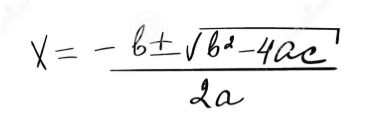

In [31]:
IMAGE_PATH = "sample_data/formula2.png"
display(Image(filename=IMAGE_PATH, width=400))

In [32]:
PROMPT = "Formula Recognition:"
results = [
    perform_ocr(IMAGE_PATH, model=GLM_OCR_MODEL, OCR_PROMPT=PROMPT),
    perform_ocr(IMAGE_PATH, model=PADDLEOCR_MODEL, OCR_PROMPT=PROMPT),
]
show_side_by_side(results)

glm-ocr $$ x = \frac {- b \pm \sqrt {b ^ {2} - 4 a c}}{2 a} $$,paddlepaddle/paddleocr-vl-1.6-gguf/paddleocr-vl-1.6-gguf.gguf x = -\frac{b \pm \sqrt{b^{2} - 4ac}}{2a}


## CHART OCR

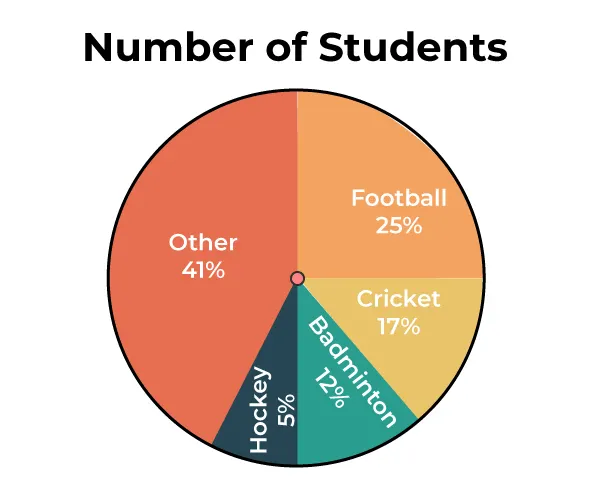

In [33]:
IMAGE_PATH = "sample_data/piechart.webp"
display(Image(filename=IMAGE_PATH, width=400))

In [34]:
PROMPT = "Chart Recognition:"
results = [
    perform_ocr(IMAGE_PATH, model=GLM_OCR_MODEL, OCR_PROMPT=PROMPT),
    perform_ocr(IMAGE_PATH, model=PADDLEOCR_MODEL, OCR_PROMPT=PROMPT),
]
show_side_by_side(results)

"glm-ocr The pie chart shows the number of students participating in various sports. Out of 100 students, 41% are playing football, 25% are playing cricket, 17% are playing badminton, 5% are playing hockey, and the remaining 10% are not participating in any sport.",paddlepaddle/paddleocr-vl-1.6-gguf/paddleocr-vl-1.6-gguf.gguf Other Football Cricket Badminton 12% 5% Hockey


## LOGO OCR

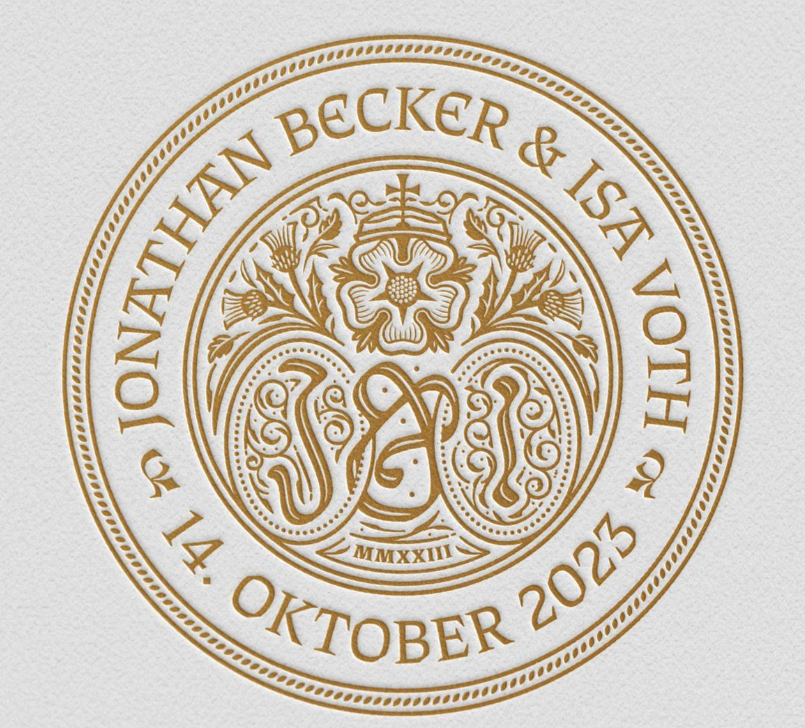

In [35]:
IMAGE_PATH = "sample_data/seal_logo.png"
display(Image(filename=IMAGE_PATH, width=400))

In [36]:
PROMPT = "Seal Recognition:"
results = [
    perform_ocr(IMAGE_PATH, model=GLM_OCR_MODEL, OCR_PROMPT=PROMPT),
    perform_ocr(IMAGE_PATH, model=PADDLEOCR_MODEL, OCR_PROMPT=PROMPT),
]
show_side_by_side(results)

glm-ocr JONATHAN BECKER & ISA VOTH 14. OKTOBER 2023 MMXXIII,paddlepaddle/paddleocr-vl-1.6-gguf/paddleocr-vl-1.6-gguf.gguf JONATHAN BECKER & ISA VOTH 14. OKTOBER 2023


---

## 👨‍💻 About Labellerr's Hands-On Learning in Computer Vision

Thank you for exploring this **Labellerr Hands-On Computer Vision Cookbook**! We hope this notebook helped you learn, prototype, and accelerate your vision projects.  
Labellerr provides ready-to-run Jupyter/Colab notebooks for the latest models and real-world use cases in computer vision, AI agents, and data annotation.

---
## 🧑‍🔬 Check Our Popular Youtube Videos

Whether you're a beginner or a practitioner, our hands-on training videos are perfect for learning custom model building, computer vision techniques, and applied AI:

- [How to Fine-Tune YOLO on Custom Dataset](https://www.youtube.com/watch?v=pBLWOe01QXU)  
  Step-by-step guide to fine-tuning YOLO for real-world use—environment setup, annotation, training, validation, and inference.
- [Build a Real-Time Intrusion Detection System with YOLO](https://www.youtube.com/watch?v=kwQeokYDVcE)  
  Create an AI-powered system to detect intruders in real time using YOLO and computer vision.
- [Finding Athlete Speed Using YOLO](https://www.youtube.com/watch?v=txW0CQe_pw0)  
  Estimate real-time speed of athletes for sports analytics.
- [Object Counting Using AI](https://www.youtube.com/watch?v=smsjBBQcIUQ)  
  Learn dataset curation, annotation, and training for robust object counting AI applications.
---

## 🎦 Popular Labellerr YouTube Videos

Level up your skills and see video walkthroughs of these tools and notebooks on the  
[Labellerr YouTube Channel](https://www.youtube.com/@Labellerr/videos):

- [How I Fixed My Biggest Annotation Nightmare with Labellerr](https://www.youtube.com/watch?v=hlcFdiuz_HI) – Solving complex annotation for ML engineers.
- [Explore Your Dataset with Labellerr's AI](https://www.youtube.com/watch?v=LdbRXYWVyN0) – Auto-tagging, object counting, image descriptions, and dataset exploration.
- [Boost AI Image Annotation 10X with Labellerr's CLIP Mode](https://www.youtube.com/watch?v=pY_o4EvYMz8) – Refine annotations with precision using CLIP mode.
- [Boost Data Annotation Accuracy and Efficiency with Active Learning](https://www.youtube.com/watch?v=lAYu-ewIhTE) – Speed up your annotation workflow using Active Learning.

> 👉 **Subscribe** for Labellerr's deep learning, annotation, and AI tutorials, or watch videos directly alongside notebooks!

---

## 🤝 Stay Connected

- **Website:** [https://www.labellerr.com/](https://www.labellerr.com/)
- **Blog:** [https://www.labellerr.com/blog/](https://www.labellerr.com/blog/)
- **GitHub:** [Labellerr/Hands-On-Learning-in-Computer-Vision](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)
- **LinkedIn:** [Labellerr](https://in.linkedin.com/company/labellerr)
- **Twitter/X:** [@Labellerr1](https://x.com/Labellerr1)

*Happy learning and building with Labellerr!*
